In [1]:
pip install pandas numpy matplotlib seaborn yfinance scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import skew, kurtosis, norm, t, ttest_1samp
import datetime

# Set the look and feel of your graphs to a clean white grid
sns.set_style("whitegrid")

In [3]:
# Define the stocks and the time period
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=365)

# Download the closing prices
print("Downloading data...")
stock_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Calculate daily log returns (Today's Price / Yesterday's Price, then taking the log)
# We use dropna() to remove the first empty row
log_returns = np.log(stock_data / stock_data.shift(1)).dropna()

# Preview the first 5 rows[cite: 1]
print("\nDaily Log Returns:")
display(log_returns.head())

[*********************100%***********************]  4 of 4 completed


Daily Log Returns:


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2025-07-15,0.002346,0.002920,0.002421,0.005551
2025-07-16,0.005009,-0.014059,0.005316,-0.000396
2025-07-17,-0.000666,0.003087,0.003328,0.011953
2025-07-18,0.005508,0.010000,0.008030,-0.003230
2025-07-21,0.006137,0.013921,0.026870,0.000020


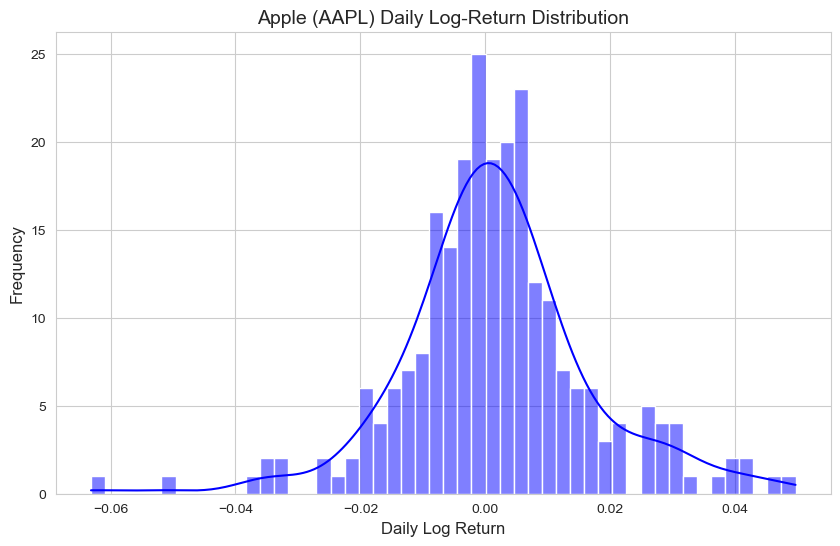

In [4]:
# Create a histogram for Apple (AAPL)[cite: 1]
plt.figure(figsize=(10, 6))
sns.histplot(log_returns['AAPL'], bins=50, kde=True, color='blue')

# Label the chart[cite: 1]
plt.title('Apple (AAPL) Daily Log-Return Distribution', fontsize=14)
plt.xlabel('Daily Log Return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [5]:
# Calculate statistics for each stock[cite: 1]
summary_stats = pd.DataFrame({
    'Mean': log_returns.mean(),
    'Variance': log_returns.var(),
    'Skewness': log_returns.apply(skew),
    'Kurtosis': log_returns.apply(kurtosis)
})

print("Summary Statistics Table:")
display(summary_stats)

Summary Statistics Table:


,Mean,Variance,Skewness,Kurtosis
Ticker,,,,
AAPL,0.001675,0.000231,-0.028200,2.231035
AMZN,0.000335,0.000384,-0.100846,2.889209
GOOGL,0.002729,0.000347,0.995880,3.653991
MSFT,-0.001041,0.000298,-0.734018,5.423243


In [6]:
# Assign equal weights to the 4 stocks (25% each)[cite: 1]
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Calculate daily portfolio returns[cite: 1]
portfolio_returns = log_returns.dot(weights)

# Calculate the portfolio's average return and standard deviation (risk)[cite: 1]
port_mean = portfolio_returns.mean()
port_std = portfolio_returns.std()

print(f"Portfolio Average Daily Return: {port_mean:.5f}")
print(f"Portfolio Daily Standard Deviation (Risk): {port_std:.5f}")

Portfolio Average Daily Return: 0.00092
Portfolio Daily Standard Deviation (Risk): 0.01203


In [7]:
# 1. Parametric VaR (Normal Distribution)[cite: 1]
# We use the z-score for 95% confidence (-1.645)[cite: 1]
z_score = norm.ppf(0.05)
parametric_var = -(port_mean + port_std * z_score)

# 2. Historical VaR[cite: 1]
# We find the exact 5th percentile from our actual past data[cite: 1]
historical_var = -np.percentile(portfolio_returns, 5)

print(f"Parametric 95% VaR: {parametric_var * 100:.2f}%")
print(f"Historical 95% VaR: {historical_var * 100:.2f}%")
print("\nInterpretation: There is a 95% chance your portfolio will not lose more than the above percentages in a single day[cite: 1].")

Parametric 95% VaR: 1.89%
Historical 95% VaR: 1.95%

Interpretation: There is a 95% chance your portfolio will not lose more than the above percentages in a single day[cite: 1].


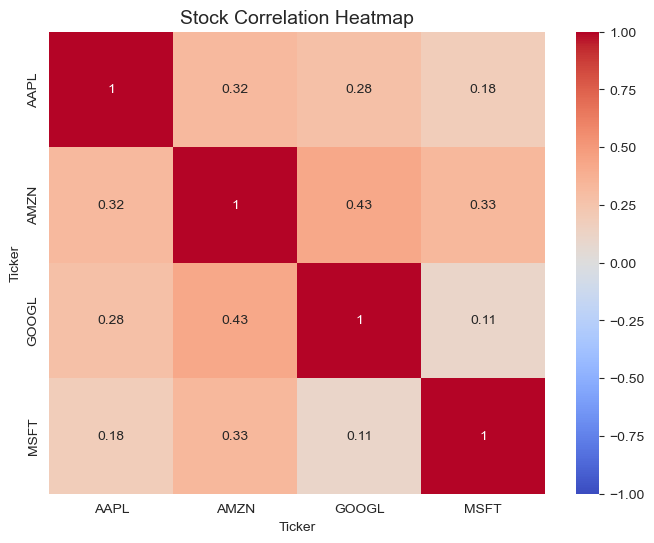

In [8]:
# Calculate how each stock moves with the others[cite: 1]
correlation_matrix = log_returns.corr()

# Create a heatmap[cite: 1]
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Stock Correlation Heatmap', fontsize=14)
plt.show()

In [9]:
# Run a one-sample t-test against a return of 0[cite: 1]
t_stat, p_value = ttest_1samp(portfolio_returns, 0)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The p-value is less than 0.05. We reject the null hypothesis. Your portfolio return is significantly different from zero[cite: 1].")
else:
    print("Conclusion: The p-value is 0.05 or higher. We cannot reject the null hypothesis. Your portfolio returns might just be due to random market noise[cite: 1].")

T-Statistic: 1.2129
P-Value: 0.2263
Conclusion: The p-value is 0.05 or higher. We cannot reject the null hypothesis. Your portfolio returns might just be due to random market noise[cite: 1].


In [10]:
# Combine all returns from all stocks into one big list
all_returns = log_returns.values.flatten()

# 1. Fit Normal Distribution
mu_norm, std_norm = norm.fit(all_returns)
print(f"Normal Distribution -> Mean: {mu_norm:.5f}, Std Dev: {std_norm:.5f}")

# 2. Fit Student's t-Distribution (Handles 'fat tails' or extreme events better)
df_t, mu_t, std_t = t.fit(all_returns)
print(f"t-Distribution -> df: {df_t:.2f}, Mean: {mu_t:.5f}, Std Dev: {std_t:.5f}\n")

# 3. Bootstrapping to find 95% Confidence Intervals[cite: 1]
print("Running Bootstrapping (Simulating 1,000 scenarios)...")
bootstrap_means = []
bootstrap_stds = []

# Resample the data 1000 times[cite: 1]
for _ in range(1000):
    sample = np.random.choice(all_returns, size=len(all_returns), replace=True)
    bootstrap_means.append(np.mean(sample))
    bootstrap_stds.append(np.std(sample))

# Get the 2.5th and 97.5th percentiles to form the 95% confidence interval[cite: 1]
ci_mean = np.percentile(bootstrap_means, [2.5, 97.5])
ci_std = np.percentile(bootstrap_stds, [2.5, 97.5])

print(f"95% Confidence Interval for Mean: [{ci_mean[0]:.5f}, {ci_mean[1]:.5f}]")
print(f"95% Confidence Interval for Std Dev (Risk): [{ci_std[0]:.5f}, {ci_std[1]:.5f}]")

Normal Distribution -> Mean: 0.00092, Std Dev: 0.01777
t-Distribution -> df: 3.82, Mean: 0.00069, Std Dev: 0.01268

Running Bootstrapping (Simulating 1,000 scenarios)...
95% Confidence Interval for Mean: [-0.00022, 0.00200]
95% Confidence Interval for Std Dev (Risk): [0.01642, 0.01912]


In [11]:
# 1. Value at Risk (VaR) using Student's t-Distribution[cite: 1]
# We use the t-distribution value at the 5% level (left tail)[cite: 1]
t_05 = t.ppf(0.05, df_t)
t_var = -(mu_t + std_t * t_05)
print(f"Student's t-Distribution 95% VaR: {t_var * 100:.2f}%")

# 2. Expected Shortfall (How bad are the worst 5% of days?)[cite: 1]
# Find the threshold for the worst 5% of historical days[cite: 1]
historical_var_threshold = np.percentile(portfolio_returns, 5)

# Calculate Historical Expected Shortfall (average loss of the worst 5% of days)[cite: 1]
worst_days = portfolio_returns[portfolio_returns <= historical_var_threshold]
historical_es = -worst_days.mean()

print(f"Historical Expected Shortfall (ES): {historical_es * 100:.2f}%")
print("Interpretation: On the worst 5% of days, this is your average expected loss[cite: 1].")

Student's t-Distribution 95% VaR: 2.67%
Historical Expected Shortfall (ES): 2.68%
Interpretation: On the worst 5% of days, this is your average expected loss[cite: 1].


Weighted Average Risk (No Diversification): 0.01767
Actual Portfolio Risk: 0.01203
Diversification Benefit: 0.00565

Maximum Drawdown (Worst Drop): -17.61%


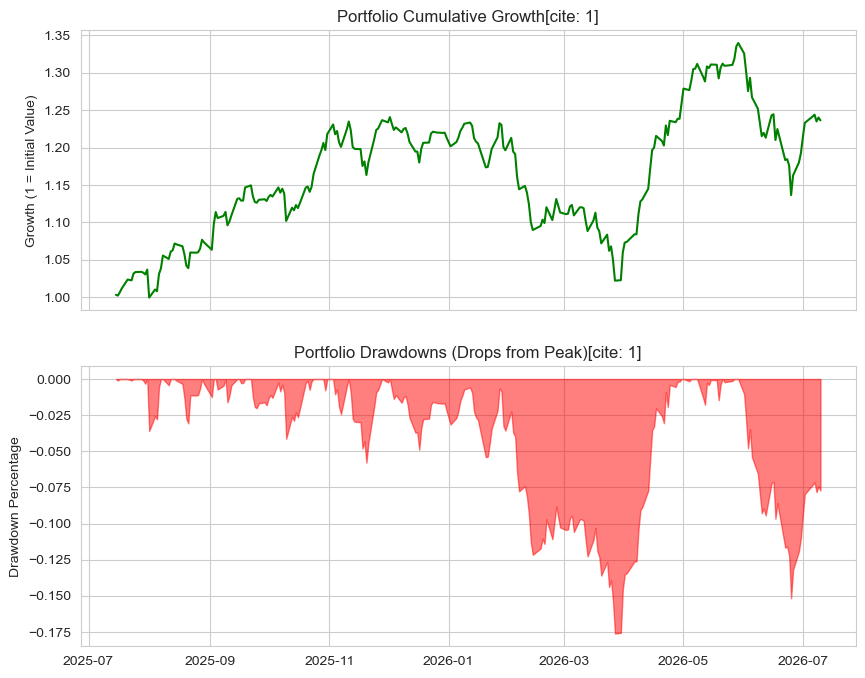

In [12]:
# 1. Diversification Benefit[cite: 1]
# Weighted average risk (if stocks acted independently) vs Actual Portfolio Risk[cite: 1]
individual_risks = log_returns.std()
weighted_avg_risk = np.dot(weights, individual_risks)
diversification_benefit = weighted_avg_risk - port_std

print(f"Weighted Average Risk (No Diversification): {weighted_avg_risk:.5f}")
print(f"Actual Portfolio Risk: {port_std:.5f}")
print(f"Diversification Benefit: {diversification_benefit:.5f}\n")

# 2. Cumulative Return & Drawdown[cite: 1]
# Build a running total of how money grows day by day[cite: 1]
cumulative_returns = (1 + portfolio_returns).cumprod()

# Track the highest value reached up to each day (peak tracker)[cite: 1]
running_max = cumulative_returns.cummax()

# Calculate Drawdown (how far the portfolio fell from its peak)[cite: 1]
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()

print(f"Maximum Drawdown (Worst Drop): {max_drawdown * 100:.2f}%")

# Visualize Growth and Drawdown[cite: 1]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Cumulative Growth[cite: 1]
ax1.plot(cumulative_returns, color='green')
ax1.set_title('Portfolio Cumulative Growth[cite: 1]')
ax1.set_ylabel('Growth (1 = Initial Value)')

# Plot Drawdowns[cite: 1]
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.5)
ax2.set_title('Portfolio Drawdowns (Drops from Peak)[cite: 1]')
ax2.set_ylabel('Drawdown Percentage')
plt.show()

VaR Exceptions: 13 days
Exception Rate: 5.22% (Should be close to 5%)[cite: 1]

Jarque-Bera P-Value: 0.04753
Conclusion: Reject Normality. Returns do NOT follow a normal distribution (bell curve)[cite: 1].



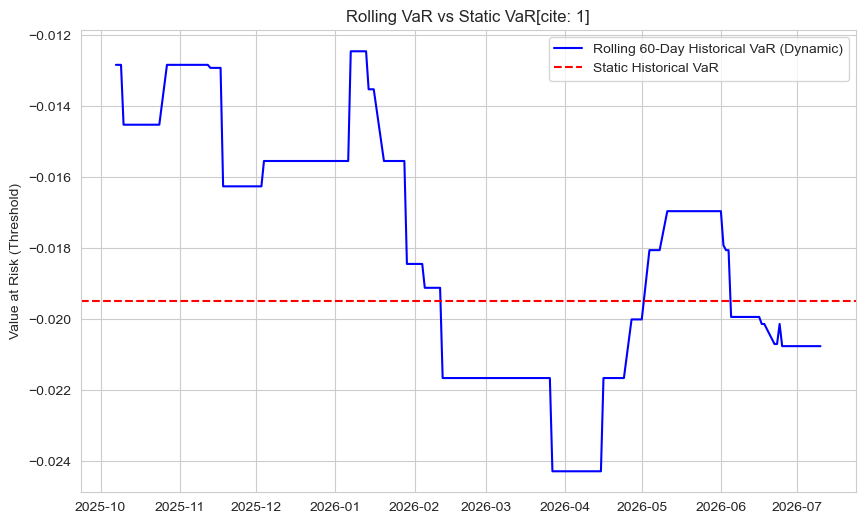

In [13]:
from scipy.stats import jarque_bera

# 1. Backtesting VaR (Did the model work?)[cite: 1]
# Recalculate historical VaR as a negative number for comparison[cite: 1]
var_threshold = np.percentile(portfolio_returns, 5) 

# Count exception days (days where actual loss was worse than VaR)[cite: 1]
exceptions = portfolio_returns[portfolio_returns < var_threshold]
exception_rate = (len(exceptions) / len(portfolio_returns)) * 100

print(f"VaR Exceptions: {len(exceptions)} days")
print(f"Exception Rate: {exception_rate:.2f}% (Should be close to 5%)[cite: 1]\n")

# 2. Jarque-Bera Test for Normality[cite: 1]
# Checks if your return data fits the shape of a bell curve[cite: 1]
jb_stat, jb_p_value = jarque_bera(portfolio_returns)
print(f"Jarque-Bera P-Value: {jb_p_value:.5f}")
if jb_p_value < 0.05:
    print("Conclusion: Reject Normality. Returns do NOT follow a normal distribution (bell curve)[cite: 1].\n")
else:
    print("Conclusion: Cannot reject Normality. Returns might follow a normal distribution[cite: 1].\n")

# 3. Rolling 60-Day Historical VaR[cite: 1]
# Calculates risk dynamically based on the most recent 60 days[cite: 1]
rolling_var = portfolio_returns.rolling(window=60).quantile(0.05)

# Plot Rolling VaR vs Static VaR[cite: 1]
plt.figure(figsize=(10, 6))
plt.plot(rolling_var, label='Rolling 60-Day Historical VaR (Dynamic)', color='blue')
plt.axhline(y=var_threshold, color='red', linestyle='--', label='Static Historical VaR')
plt.title('Rolling VaR vs Static VaR[cite: 1]')
plt.ylabel('Value at Risk (Threshold)')
plt.legend()
plt.show()